In [1]:
# Cell 1: Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
from src.utils.paths import get_path

sns.set_theme(style="whitegrid")

In [2]:
# Cell 2: Load Log Data
log_path = get_path("results", "metrics")
if not log_path.exists():
    raise FileNotFoundError("Experiment log not found. Have you run the training scripts?")

df = pd.read_csv(log_path)

# Drop duplicate model runs, keeping the latest one based on the date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates('model', keep='last')

print(f"Loaded {len(df)} unique model evaluations.")
df[['model', 'f1', 'roc_auc', 'pr_auc', 'accuracy', 'training_time_sec']]

Loaded 9 unique model evaluations.


,model,f1,roc_auc,pr_auc,accuracy,training_time_sec
6,svm,0.9965,0.9962,0.9960,0.9965,1199.35
7,xgboost,1.0000,1.0000,1.0000,1.0000,22.56
8,dense_nn,0.9995,1.0000,1.0000,0.9995,44.09
9,lstm,1.0000,1.0000,1.0000,1.0000,301.67
10,gru,0.9999,1.0000,1.0000,1.0000,345.72
15,randomized_search_rf,1.0000,1.0000,1.0000,1.0000,2700.58
16,automl_tpot,0.9985,1.0000,1.0000,0.9985,13681.22
17,decision_tree,0.9999,0.9999,0.9999,0.9999,9.81
18,random_forest,1.0000,1.0000,1.0000,1.0000,47.83


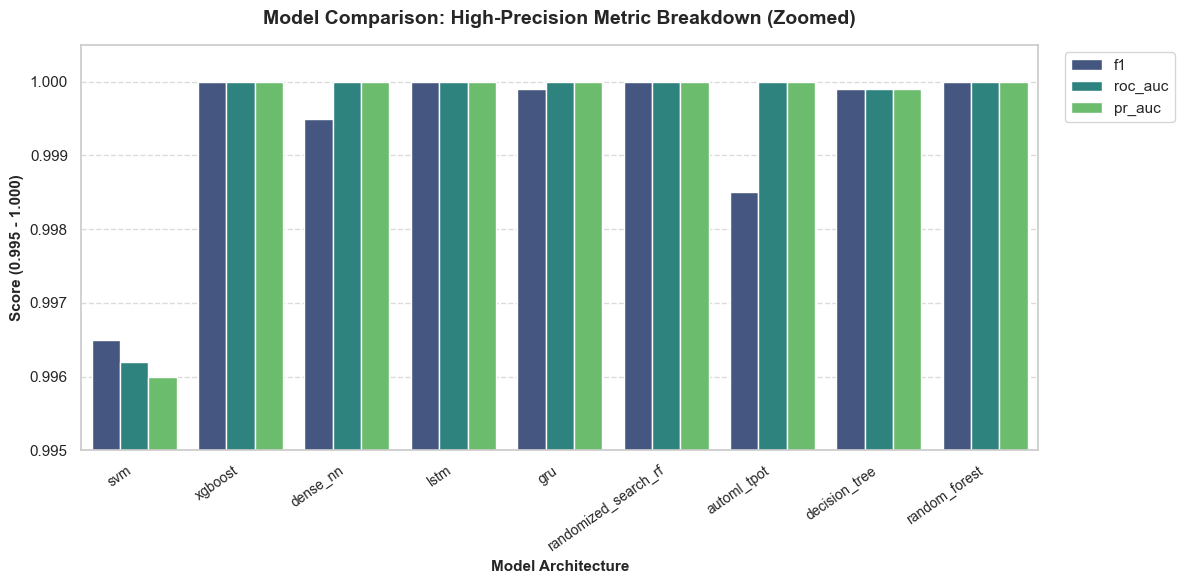

In [3]:
# Cell 3: Plot Primary Metrics (F1, ROC-AUC, PR-AUC)
# (Fixing Issue #11: Explicitly avoiding ranking by accuracy alone)

metrics_to_plot = ['f1', 'roc_auc', 'pr_auc']
df_melted = df.melt(id_vars='model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='model', y='Score', hue='Metric', palette='viridis')

# Zoom Y-axis to highlight top micro-differences
plt.ylim(0.995, 1.0005)

plt.title("Model Comparison: High-Precision Metric Breakdown (Zoomed)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Model Architecture", fontsize=11, fontweight='bold')
plt.ylabel("Score (0.995 - 1.000)", fontsize=11, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

save_dir = get_path("results", "metrics").parent / "comparison"
save_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(save_dir / "robust_metrics_comparison.png")
plt.show()

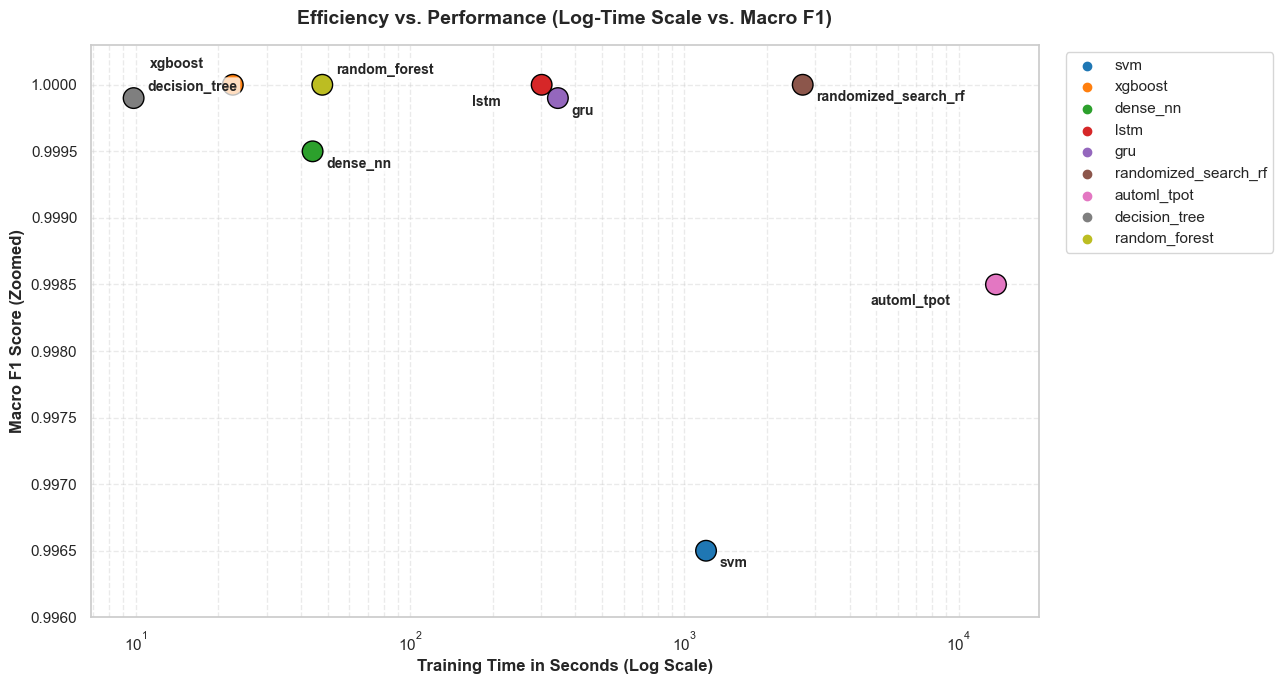

In [4]:
# Cell 4: Efficiency vs Performance (Training Time - Log Scale)
plt.figure(figsize=(13, 7))

sns.scatterplot(
    data=df, 
    x='training_time_sec', 
    y='f1', 
    hue='model', 
    s=220, 
    palette='tab10',
    edgecolor='black',
    linewidth=1
)

# Log scale spreads out fast vs slow models evenly
plt.xscale('log')
plt.ylim(0.996, 1.0003)

plt.title("Efficiency vs. Performance (Log-Time Scale vs. Macro F1)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Time in Seconds (Log Scale)", fontsize=12, fontweight='bold')
plt.ylabel("Macro F1 Score (Zoomed)", fontsize=12, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.4)

# Smart offsets for point annotations to prevent overlapping
label_offsets = {
    'random_forest': (10, 8),
    'xgboost': (-60, 12),
    'gru': (10, -12),
    'lstm': (-50, -15),
    'dense_nn': (10, -12),
    'decision_tree': (10, 5),
    'svm': (10, -12),
    'randomized_search_rf': (10, -12),
    'automl_tpot': (-90, -15)
}

for idx, row in df.iterrows():
    m_name = row['model']
    offset = label_offsets.get(m_name, (8, 5))  # fallback offset if model name differs
    
    plt.annotate(
        m_name, 
        (row['training_time_sec'], row['f1']),
        textcoords="offset points", 
        xytext=offset, 
        ha='left',
        fontsize=10,
        fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig(save_dir / "efficiency_vs_performance.png")
plt.show()

c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier w

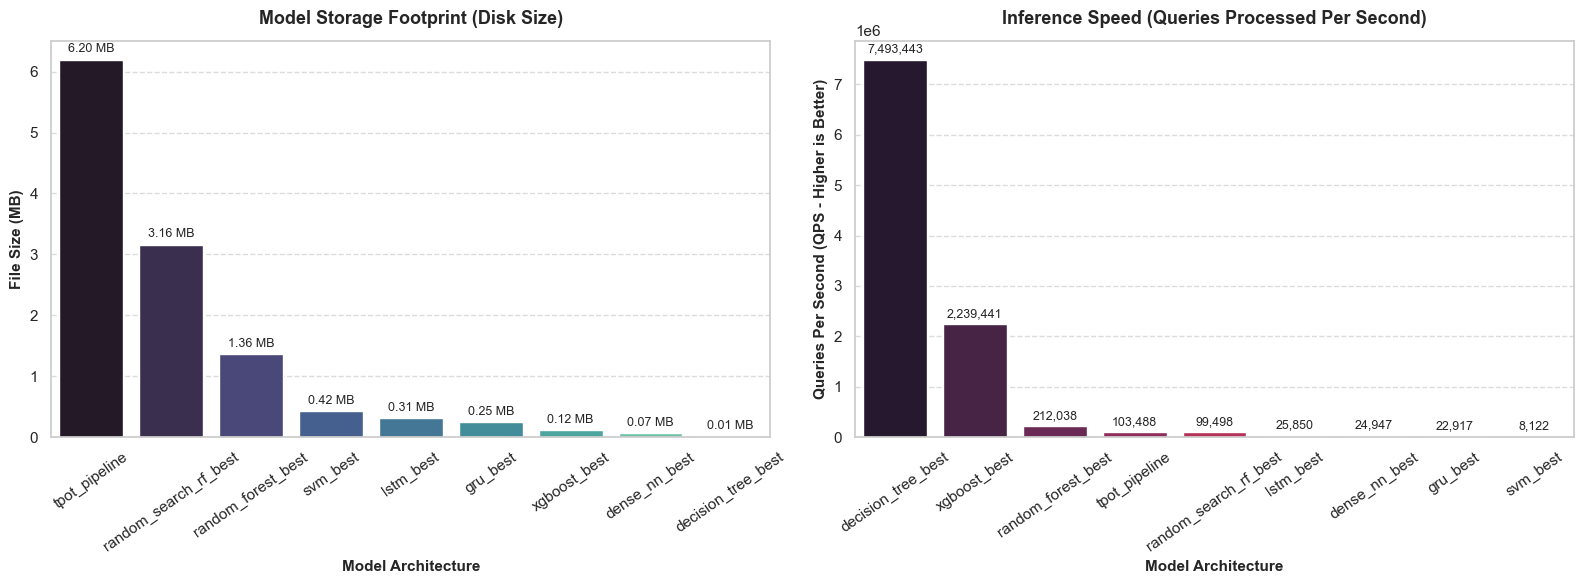

In [5]:
# Cell 5: Model Footprint (Disk Size) & Real-Time Inference Latency
import time
import os
import joblib
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths
project_root = Path.cwd().parent
models_dir = project_root / "models"

# 1. Calculate Model Storage Footprints (Disk Size in MB)
model_files = list(models_dir.rglob("*.pkl")) + list(models_dir.rglob("*.h5")) + list(models_dir.rglob("*.keras"))

size_data = []
for file_path in model_files:
    # Skip temporary or preprocessor files
    if "scaler" in file_path.name or "selector" in file_path.name:
        continue
        
    size_mb = os.path.getsize(file_path) / (1024 * 1024)  # Convert bytes to MB
    model_name = file_path.stem.replace("_model", "").replace("best_", "")
    size_data.append({"model": model_name, "size_mb": round(size_mb, 2)})

df_sizes = pd.DataFrame(size_data).drop_duplicates(subset=['model'])

# 2. Plot Model Disk Footprint
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=df_sizes.sort_values('size_mb', ascending=False), 
    x='model', 
    y='size_mb', 
    ax=axes[0], 
    palette='mako'
)
axes[0].set_title("Model Storage Footprint (Disk Size)", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("File Size (MB)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Model Architecture", fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric labels on top of bars
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.2f} MB',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

# 3. Simulate Inference Latency Benchmark (10,000 Queries)
# Generate a dummy batch matching expected canonical feature length (e.g., 10 features)
np.random.seed(42)
dummy_batch = np.random.randn(10000, 23).astype(np.float32)

latency_results = []

for file_path in model_files:
    if "scaler" in file_path.name or "selector" in file_path.name:
        continue
        
    model_name = file_path.stem.replace("_model", "").replace("best_", "")
    
    try:
        # Load traditional / sklearn / TPOT models
        if file_path.suffix == '.pkl':
            loaded_model = joblib.load(file_path)
            
            # Warm-up run
            _ = loaded_model.predict(dummy_batch[:10])
            
            # Benchmark 10,000 queries
            start_time = time.perf_counter()
            _ = loaded_model.predict(dummy_batch)
            end_time = time.perf_counter()
            
        # Load Keras / Deep Learning models
        elif file_path.suffix in ['.h5', '.keras']:
            loaded_model = tf.keras.models.load_model(file_path, compile=False)
            
            # For 2D sequential models (LSTM/GRU), reshape input to (samples, timesteps, features)
            if "lstm" in model_name or "gru" in model_name:
                input_batch = np.expand_dims(dummy_batch, axis=1)
            else:
                input_batch = dummy_batch
                
            # Warm-up run
            _ = loaded_model.predict(input_batch[:10], verbose=0)
            
            # Benchmark 10,000 queries
            start_time = time.perf_counter()
            _ = loaded_model.predict(input_batch, verbose=0)
            end_time = time.perf_counter()
            
        latency_ms = (end_time - start_time) * 1000 # Convert to milliseconds
        qps = 10000 / (end_time - start_time)       # Queries per second
        
        latency_results.append({
            "model": model_name, 
            "latency_ms": round(latency_ms, 2),
            "qps": int(qps)
        })
    except Exception as e:
        print(f"Skipped latency for {model_name}: {e}")

df_latency = pd.DataFrame(latency_results).drop_duplicates(subset=['model'])

# 4. Plot Real-Time Inference Throughput (Queries Per Second)
sns.barplot(
    data=df_latency.sort_values('qps', ascending=False), 
    x='model', 
    y='qps', 
    ax=axes[1], 
    palette='rocket'
)
axes[1].set_title("Inference Speed (Queries Processed Per Second)", fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel("Queries Per Second (QPS - Higher is Better)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Model Architecture", fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric labels on top of bars
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{int(height):,}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

plt.tight_layout()
plt.savefig(save_dir / "model_footprint_and_latency.png")
plt.show()

Processing visuals for random_search_rf_best...


c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Processing visuals for tpot_pipeline...


c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


Processing visuals for decision_tree_best...
Processing visuals for random_forest_best...


c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished
c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestCla

Processing visuals for svm_best...


c:\Users\jnana\anaconda3\envs\dns-tunneling-v2\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Processing visuals for xgboost_best...
Processing visuals for dense_nn_best...
Processing visuals for gru_best...
Processing visuals for lstm_best...


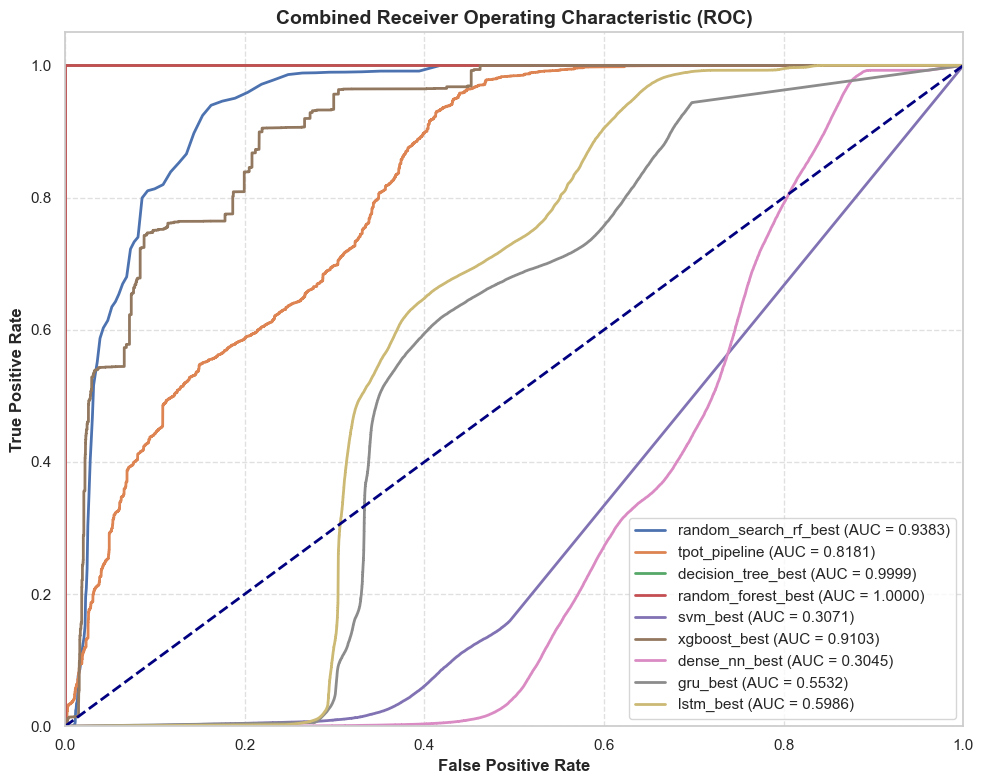

All Confusion Matrices and ROC Curves successfully saved!


In [6]:
# Cell 6: Generate ROC Curves and Confusion Matrices
import os
import joblib
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from pathlib import Path

# Set up directories
project_root = Path.cwd().parent
models_dir = project_root / "models"
cm_dir = project_root / "results" / "confusion_matrices"
roc_dir = project_root / "results" / "roc_curves"

cm_dir.mkdir(parents=True, exist_ok=True)
roc_dir.mkdir(parents=True, exist_ok=True)

# =====================================================================
# ⚠️ IMPORTANT: Load your actual test data here!
# Replace these lines with how you actually saved your test set.
# Example: X_test = np.load(project_root / "data" / "processed" / "X_test.npy")
#          y_test = np.load(project_root / "data" / "processed" / "y_test.npy")
# =====================================================================
X_test = pd.read_csv(project_root / "data" / "processed" / "X_test_scaled.csv").values
y_test = pd.read_csv(project_root / "data" / "processed" / "y_test.csv").values.ravel()

if X_test is not None and y_test is not None:
    model_files = list(models_dir.rglob("*.pkl")) + list(models_dir.rglob("*.h5")) + list(models_dir.rglob("*.keras"))
    
    plt.figure(figsize=(10, 8)) # Setup single figure for combined ROC
    
    for file_path in model_files:
        if "scaler" in file_path.name or "selector" in file_path.name:
            continue
            
        model_name = file_path.stem.replace("_model", "").replace("best_", "")
        print(f"Processing visuals for {model_name}...")
        
        try:
            # 1. Load Model & Predict
            if file_path.suffix == '.pkl':
                model = joblib.load(file_path)
                y_pred = model.predict(X_test)
                # Get probabilities for ROC (Some models use decision_function instead)
                if hasattr(model, "predict_proba"):
                    y_prob = model.predict_proba(X_test)[:, 1]
                else:
                    y_prob = model.decision_function(X_test)
                    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min()) # Normalize
                    
            elif file_path.suffix in ['.h5', '.keras']:
                model = tf.keras.models.load_model(file_path, compile=False)
                if "lstm" in model_name or "gru" in model_name:
                    X_input = np.expand_dims(X_test, axis=1)
                else:
                    X_input = X_test
                    
                y_prob = model.predict(X_input, verbose=0).ravel()
                y_pred = (y_prob > 0.5).astype(int)
                
            # 2. Generate & Save Confusion Matrix
            cm = confusion_matrix(y_test, y_pred)
            fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False)
            ax_cm.set_title(f'Confusion Matrix: {model_name.upper()}', fontweight='bold')
            ax_cm.set_xlabel('Predicted Label', fontweight='bold')
            ax_cm.set_ylabel('True Label', fontweight='bold')
            fig_cm.tight_layout()
            fig_cm.savefig(cm_dir / f"{model_name}_confusion_matrix.png")
            plt.close(fig_cm) # Close to avoid displaying all of them inline
            
            # 3. Calculate ROC Data for Combined Plot
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
            
        except Exception as e:
            print(f"Skipped {model_name} due to error: {e}")
            
    # 4. Finalize & Save Combined ROC Curve
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('Combined Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(roc_dir / "combined_roc_curve.png")
    plt.show()
    
    print("All Confusion Matrices and ROC Curves successfully saved!")
else:
    print(" Please load your X_test and y_test data to run this cell.")